# Animal vs Vehicle Recognition with CIFAR-10

## Project objective
This project aims to build a convolutional neural network (CNN) that distinguishes between animal and vehicle images, using the CIFAR-10 dataset. The goal is to create a binary classifier that separates the two semantic groups: animals (bird, cat, deer, dog, frog, horse) and vehicles (airplane, automobile, ship, truck).

## Why this task matters
The model is designed as a demonstration of image classification for road-safety and urban monitoring scenarios. In a real-world context, a system like this could support early detection of wildlife crossings or improve the analysis of visual inputs in autonomous-driving or surveillance applications.

## Dataset
The project uses CIFAR-10, a benchmark dataset composed of 60,000 color images of size 32x32. Each image belongs to one of 10 classes. For this project, the original labels are remapped into a binary target: 1 for animal classes and 0 for vehicle classes.

## Workflow
1. Load CIFAR-10
2. Normalize image pixels to the [0, 1] range
3. Flatten labels and convert them to a binary target
4. Build a CNN for binary classification
5. Train the model and monitor training and validation metrics
6. Evaluate precision, recall, confusion matrix, and sample errors

## Model overview
The network uses a standard CNN structure with convolutional layers, batch normalization, max pooling, dropout, and a final sigmoid output layer. Because the task is binary classification, the final layer contains a single neuron with sigmoid activation.

## Evaluation metrics
The model is evaluated using accuracy, precision, recall, and loss. Validation metrics are especially important because they indicate how well the model generalizes to unseen data. In addition, the confusion matrix and error analysis help identify misclassified cases and assess class-specific weaknesses.


In [1]:
#say no to warnings!
import warnings
warnings.filterwarnings("ignore")
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

gpus = tf.config.list_physical_devices('GPU')
print(gpus)

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True);

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1787928682.142880    7070 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1787928682.257945    7070 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1787928682.258019    7070 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


## Library imports and environment setup

### Required libraries are imported for the project, including NumPy, pickle, Matplotlib, and TensorFlow/Keras. The environment is also configured to enable GPU usage when available.


In [19]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import InputLayer, Input, Conv2D, Dense, Flatten, Dropout, MaxPool2D, BatchNormalization,Activation
from tensorflow.keras.models import Model
from tensorflow.keras.backend import clear_session

## Dataset loading and class mapping

The CIFAR-10 dataset is loaded directly from Keras. Each image belongs to one of 10 original classes, and the labels are then mapped into the binary task required by the project: animals receive label 1 and vehicles receive label 0. The lists of animal and vehicle classes are used to create the binary target in a consistent way.


In [20]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [21]:
cifar10 = tf.keras.datasets.cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


In [22]:
animals = ['bird', 'cat', 'deer', 'dog', 'frog', 'horse']
animals = [labels.index(x) for x in animals]

In [23]:
vehicles = ['airplane', 'automobile', 'ship', 'truck']
vehicles = [labels.index(x) for x in vehicles]

## Preprocessing and normalization

Pixel values are normalized from the original 0-255 range to [0, 1] to improve learning stability. The labels are flattened from a shape of (N, 1) to a one-dimensional array so they match the format expected by Keras during training and validation.


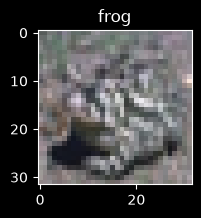

In [24]:
plt.figure(figsize=(2,2))
indx = np.random.choice(range(50000))
plt.imshow(x_train[indx])
plt.title(labels[y_train[indx][0]]);

In [25]:
# Normalizzazione: i pixel vanno da 0-255, dividi per 255 per portarli in range 0-1. La rete neurale impara meglio con valori piccoli.
x_train, x_test = x_train/255., x_test/255.
#  Appiattimento: CIFAR10 restituisce le label con shape (50000, 1), ma Keras le vuole come (50000,), un array semplice monodimensionale.
y_train, y_test = y_train.flatten(), y_test.flatten()

# Rimappiamo le 10 classi CIFAR10 in un problema binario: 0 = veicolo, 1 = animale
y_train_original, y_test_original = y_train.copy(), y_test.copy()  # tenute per eventuale analisi per-classe
y_train = np.isin(y_train, animals).astype('float32')
y_test = np.isin(y_test, animals).astype('float32')
print('Distribuzione classi (train):', np.unique(y_train, return_counts=True))
print('Distribuzione classi (test):', np.unique(y_test, return_counts=True))

Distribuzione classi (train): (array([0., 1.], dtype=float32), array([20000, 30000]))
Distribuzione classi (test): (array([0., 1.], dtype=float32), array([4000, 6000]))


## CNN architecture

A compact CNN is built for binary classification. The model uses convolutional layers, batch normalization, pooling operations, dropout regularization, and a final sigmoid output neuron. The sigmoid is chosen because the task is binary: the network predicts the probability that an image belongs to the animal class.


In [26]:
import os
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0'
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"

In [27]:
clear_session()
cnn1 = Sequential([
    InputLayer(input_shape=(32,32,3)),
    Conv2D(32, kernel_size=(3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=(2,2)),
    Conv2D(128, kernel_size=(3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(.5),
    Dense(1, activation='sigmoid')
])

## Training configuration

The model is compiled with binary cross-entropy, which is the standard loss for a binary classifier. Accuracy, precision, and recall are tracked to monitor both overall learning and class-level behavior. Early stopping is enabled to stop training when validation loss stops improving, and a checkpoint saves the best model automatically.


In [28]:
cnn1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,545 (1.36 MB)

 Trainable params: 356,097 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [29]:
from keras.src.callbacks import EarlyStopping
from tensorflow.keras.metrics import Precision, Recall

cnn1.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')],
              jit_compile=False)
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1,mode='min')

## Training and interpretation
Training is performed with the binary cross-entropy loss and standard Adam optimization. An early stopping callback is applied to prevent unnecessary training when the validation loss stops improving. The best model is saved automatically based on the lowest validation loss.

## Expected results
A successful model should show a stable decrease in training loss and a strong validation accuracy, while keeping precision and recall high. The confusion matrix and image-level error analysis provide a deeper understanding of which categories are easier or harder to distinguish.

## Final note
This project is a practical demonstration of how a CNN can solve a binary image-classification problem using a standard benchmark dataset. The main goal is not only to reach high accuracy, but also to understand the learning dynamics, failure cases, and quality of the final model.


In [30]:
%%time
hist1 = cnn1.fit(x_train, y_train, epochs=50, validation_data=(x_test, y_test), callbacks=[early_stopping])

Epoch 1/50
1262/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8906 - loss: 0.2791 - precision: 0.9035 - recall: 0.9153CPU times: user 21.8 s, sys: 15.4 s, total: 37.2 s
Wall time: 33.8 s


KeyboardInterrupt: 

## Evaluation and diagnosis

After training, the model is evaluated on the test set using accuracy, precision, recall, loss, and the confusion matrix. Additional plots and error analysis help identify common failure cases and provide a more reliable interpretation of the final model quality.


In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(hist1.history['accuracy'], label='accuracy')
plt.plot(hist1.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(hist1.history['loss'], label='loss')
plt.plot(hist1.history['val_loss'], label='val_loss')
plt.legend();

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Predizioni sul test set (probabilita' -> classe binaria con soglia 0.5)
y_prob = cnn1.predict(x_test).flatten()
y_pred = (y_prob > 0.5).astype(int)

print(classification_report(y_test.astype(int), y_pred, target_names=['veicolo', 'animale']))

In [ ]:
# Matrice di confusione: aiuta a vedere quali classi si confondono di piu'
cm = confusion_matrix(y_test.astype(int), y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['veicolo', 'animale'])
disp.plot(cmap='Blues')
plt.title('Matrice di confusione - veicolo vs animale');

In [ ]:
# Analisi degli errori: quali classi originali (0-9) vengono confuse piu' spesso
errors_mask = y_pred != y_test.astype(int)
errors_by_class = {}
for lbl_idx, lbl_name in enumerate(labels):
    class_mask = (y_test_original == lbl_idx)
    n_total = class_mask.sum()
    n_errors = (errors_mask & class_mask).sum()
    errors_by_class[lbl_name] = (n_errors, n_total, n_errors / n_total if n_total else 0)

print(f"{'Classe':12s} {'Errori':>7s} {'Totale':>7s} {'% Errore':>9s}")
for lbl_name, (n_err, n_tot, rate) in sorted(errors_by_class.items(), key=lambda kv: -kv[1][2]):
    print(f"{lbl_name:12s} {n_err:7d} {n_tot:7d} {rate*100:8.2f}%")

In [ ]:
# Visualizziamo alcune immagini classificate erroneamente
error_indices = np.where(errors_mask)[0]
sample_errors = np.random.choice(error_indices, size=min(9, len(error_indices)), replace=False)

plt.figure(figsize=(9,9))
for i, idx in enumerate(sample_errors):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[idx])
    true_lbl = labels[y_test_original[idx]]
    pred_lbl = 'animale' if y_pred[idx] == 1 else 'veicolo'
    plt.title(f'vero: {true_lbl}\npredetto: {pred_lbl}', fontsize=9)
    plt.axis('off')
plt.tight_layout();